This script plots various aspects of the TrappedResonance objective function

In [63]:
import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [66]:
# User Inputs #
eq = desc.io.load("equil_G1600_DESC_fixed.h5")

rhos = (np.linspace(0.1,0.9,50))**(1/2) # rho = sqrt(s)
alphas = np.linspace(0,2*np.pi,3)
KE_frac = np.array([1]) #did 0.001 before
pitch_invs = jnp.linspace(6.0,6.1,1)
N=0 # QA

In [67]:
# Run objective function
def TrappedResonanceObj(rhos,pitch_invs,KE_frac,alphas,N):
    obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=N)
    obj.build()
    out = obj.compute(eq.params_dict) # when not flattened, this shape is (rho,pitch,energy)

    # Save objective function values to the firm3d directory for plotting with Poincare plots
    np.savetxt('/Users/paullab/codes/firm3d_fork_10132025/firm3d/examples/trapped_map/obj_DESC.txt',out['obj'][:,0,0]) # value at all surfaces and one pitch (and one energy)
    return out

Precomputing transforms


In [70]:
# testing
psi_da = out['psi_da']
obj_out = out['obj']
omega = out['omega']
# print(rhos**2) # index 12 is roughly s=0.6
print(omega[:,0,0,0])

[-2.22331260e-01 -2.23417905e-01 -2.34133823e-01 -1.88095926e-01
 -1.55891796e-01 -1.42395536e-01 -1.25318496e-01 -1.00311697e-01
 -8.38432594e-02 -7.53160024e-02 -6.97129180e-02 -6.44777513e-02
 -5.89954416e-02 -5.36390725e-02 -4.89237757e-02 -4.49877545e-02
 -4.17583200e-02 -3.90010022e-02 -3.64880488e-02 -3.40656168e-02
 -3.16087629e-02 -2.90890236e-02 -2.65680132e-02 -2.40813657e-02
 -2.17279334e-02 -1.95389705e-02 -1.74611477e-02 -1.54682910e-02
 -1.34043222e-02 -1.10583345e-02 -8.21451809e-03 -4.50140697e-03
  2.08059074e-04  5.84062666e-03  1.18464844e-02  1.74947419e-02
  2.24351163e-02  2.67169264e-02  3.10551981e-02  3.67028995e-02
  4.46118568e-02  5.44624220e-02  6.49024948e-02  7.20696768e-02
  7.08041841e-02  6.30330280e-02  5.24829845e-02  3.69072525e-02
  1.77906504e-02  1.14733423e-02]


ValueError: x and y must have same first dimension, but have shapes (50,) and (10,)

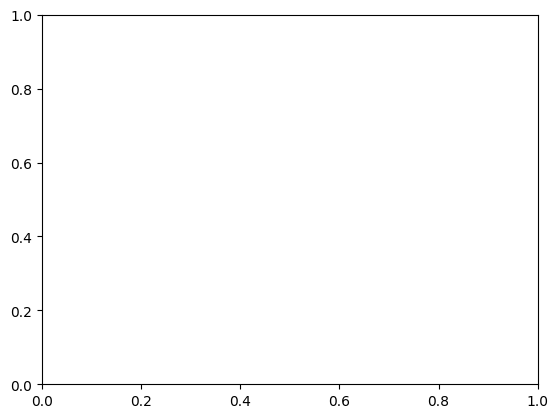

In [68]:
# Plot s vs. obj_out for each pitch inverse
for i in range(0,obj_out.shape[1]): # loop through each pitch angle
    plt.figure(i+1)
    plt.plot(rhos**2,obj_out[:,i,0]) # assuming we are only doing 1 energy for now
    plt.xlabel(r'$s$')
    plt.ylabel('Objective Function Value')
    plt.title('TrappedResonance Objective Function Value for Pitch Inverse = '+str(pitch_invs[i]))
    # plt.ylabel(r'$\omega_{\zeta}$')
    # plt.title(r'$\omega_{\zeta}$ Value for Pitch Inverse = '+str(pitch_invs[i]))
    plt.xlim([0.0,1.0])

Text(0, 0.5, 'Objective Function Value')

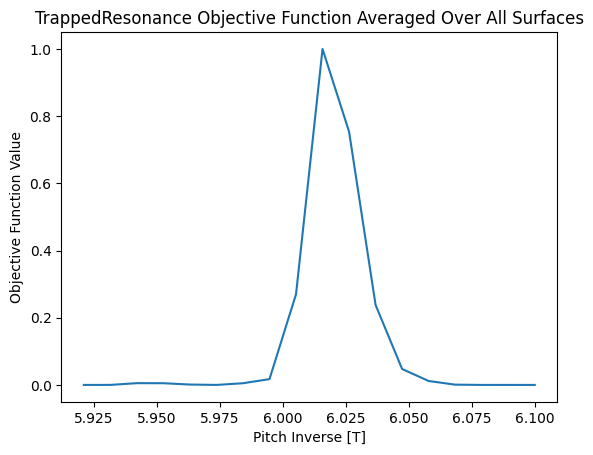

In [62]:
# Plot the value of the TrappedResonance objective (summing over the rho axis) vs. pitch
obj_out = out['obj']
num_valid_pitch = jnp.sum(obj_out!=0,axis=0) # for each surface, how many pitches were valid

obj_out_rhosum = np.sum(obj_out,axis=0) / num_valid_pitch
np.savetxt('obj_pitch_plot.txt',obj_out_rhosum[:,0])
plt.figure()
plt.plot(pitch_invs,obj_out_rhosum[:,0]/np.nanmax(obj_out_rhosum[:,0]))
plt.title("TrappedResonance Objective Function Averaged Over All Surfaces")
plt.xlabel("Pitch Inverse [T]")
plt.ylabel("Objective Function Value")

In [51]:
np.savetxt('obj_s_out.txt',out['obj'][:,0,0]) # value at all surfaces

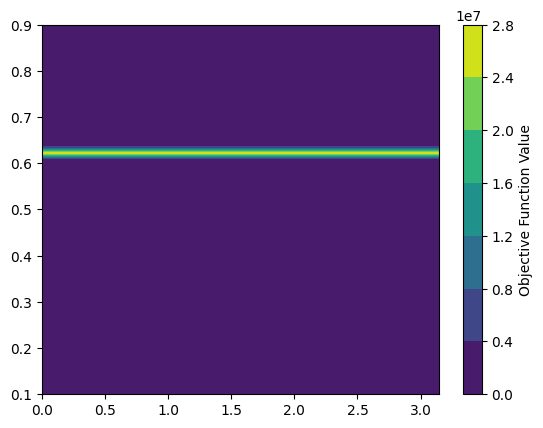

In [69]:
obj_val = out['obj'][:,0,0]
Y = rhos**2
X = np.linspace(0,np.pi,5)
Z = np.transpose(np.tile(obj_val, (5, 1)))
plt.contourf(X,Y,Z)
plt.colorbar(label='Objective Function Value')